Đã nạp dữ liệu thành công! Kích thước bảng: (4614, 9)


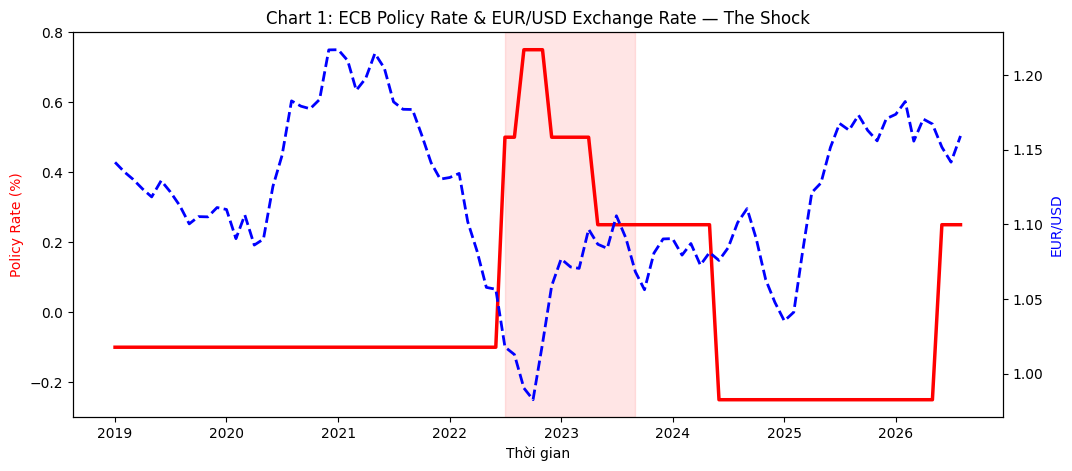

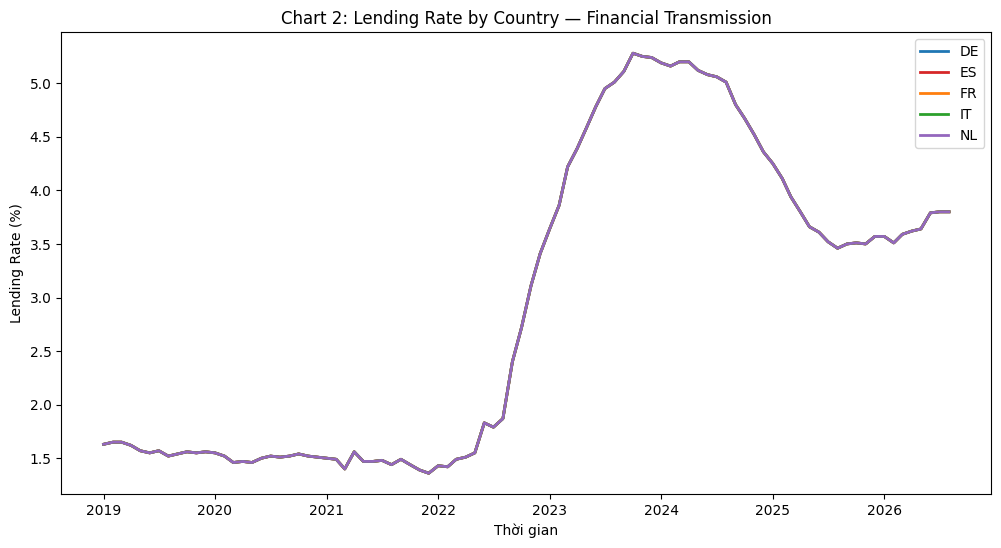

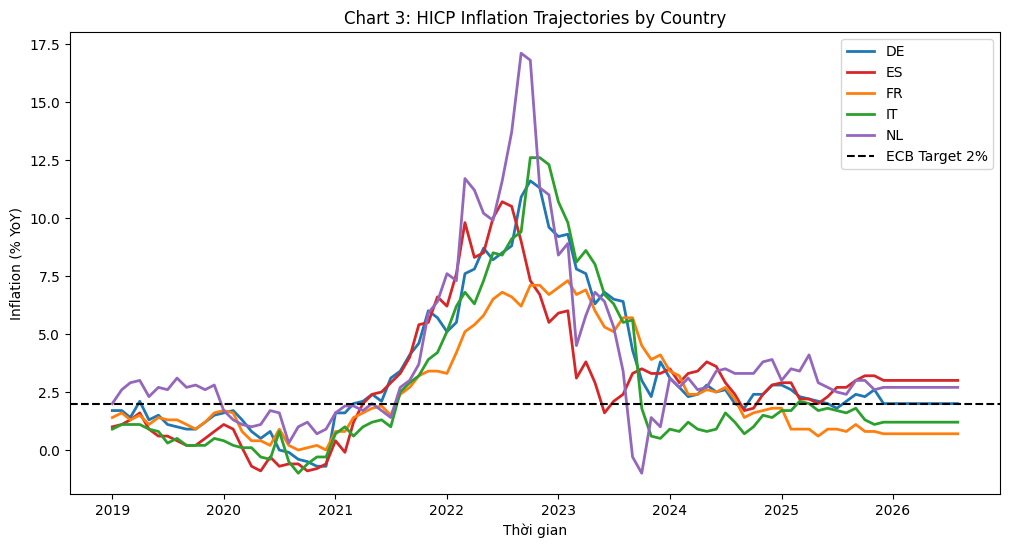

Toàn bộ biểu đồ đã được vẽ thành công tuyệt đối!


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Đọc file dataset trực tiếp từ thư mục data_clean
df = pd.read_csv("C:\\Users\\Viet Hung\\Downloads\\gois1-1109\\data_clean\\master_dataset.csv")

# Chuẩn hóa tên cột từ viết hoa sang viết thường để dễ code, hoặc giữ nguyên tùy ý
df = df.rename(columns={
    'Country': 'country',
    'Date': 'date',
    'Inflation': 'hicp_inflation',
    'Unemployment': 'unemployment_rate',
    'GDP_Value': 'gdp_growth',
    'Credit_Growth': 'credit_m3',
    'Policy_Rate': 'policy_rate',
    'EUR_USD': 'eur_usd',
    'Lending_Rate': 'lending_rate'
})

df['date'] = pd.to_datetime(df['date'])
print("Đã nạp dữ liệu thành công! Kích thước bảng:", df.shape)

# Bảng màu cố định theo quốc gia
colors = {'DE': '#1f77b4', 'FR': '#ff7f0e', 'IT': '#2ca02c', 'ES': '#d62728', 'NL': '#9467bd'}

# ==========================================================
# CHART 1: ECB Policy Rate & EUR/USD
# ==========================================================
policy_df = df.groupby("date", as_index=False)[["policy_rate", "eur_usd"]].mean()

fig, ax1 = plt.subplots(figsize=(12, 5))
ax1.plot(policy_df["date"], policy_df["policy_rate"], color="red", linewidth=2.5, label="Policy Rate (%)")
ax1.set_ylabel("Policy Rate (%)", color="red")
ax1.set_xlabel("Thời gian")

ax2 = ax1.twinx()
ax2.plot(policy_df["date"], policy_df["eur_usd"], color="blue", linewidth=2, linestyle="--", label="EUR/USD")
ax2.set_ylabel("EUR/USD", color="blue")

ax1.axvspan(pd.to_datetime("2022-07-01"), pd.to_datetime("2023-09-01"), color="red", alpha=0.1, label="Tightening Period")
plt.title("Chart 1: ECB Policy Rate & EUR/USD Exchange Rate — The Shock")
plt.show()

# ==========================================================
# CHART 2: Lending Rate by Country
# ==========================================================
plt.figure(figsize=(12, 6))
for country, grp in df.groupby("country"):
    plt.plot(grp["date"], grp["lending_rate"], label=country, color=colors.get(country, "black"), linewidth=2)
plt.title("Chart 2: Lending Rate by Country — Financial Transmission")
plt.ylabel("Lending Rate (%)")
plt.xlabel("Thời gian")
plt.legend()
plt.show()

# ==========================================================
# CHART 3: HICP Inflation Trajectories
# ==========================================================
plt.figure(figsize=(12, 6))
for country, grp in df.groupby("country"):
    plt.plot(grp["date"], grp["hicp_inflation"], label=country, color=colors.get(country, "black"), linewidth=2)
plt.axhline(y=2, color="black", linestyle="--", label="ECB Target 2%")
plt.title("Chart 3: HICP Inflation Trajectories by Country")
plt.ylabel("Inflation (% YoY)")
plt.xlabel("Thời gian")
plt.legend()
plt.show()

print("Toàn bộ biểu đồ đã được vẽ thành công tuyệt đối!")

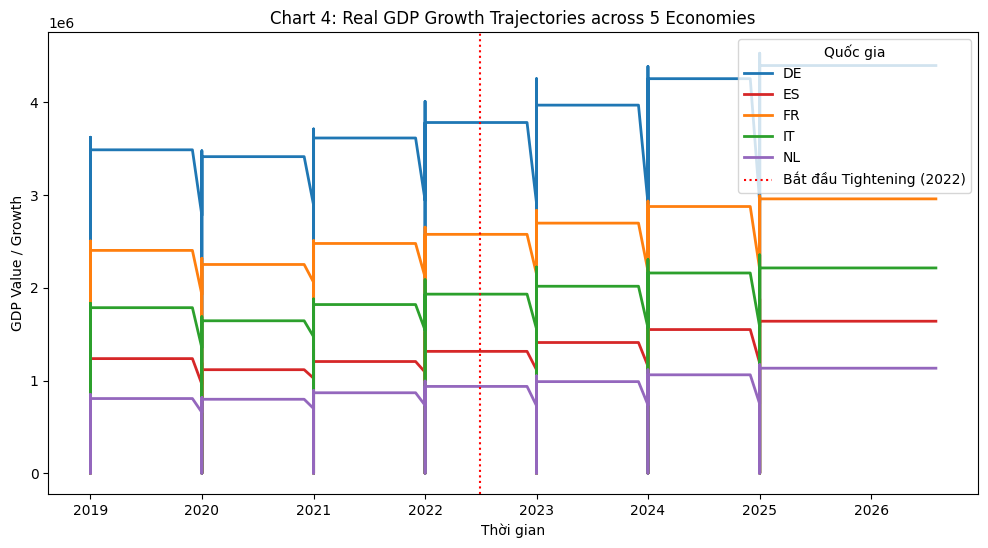

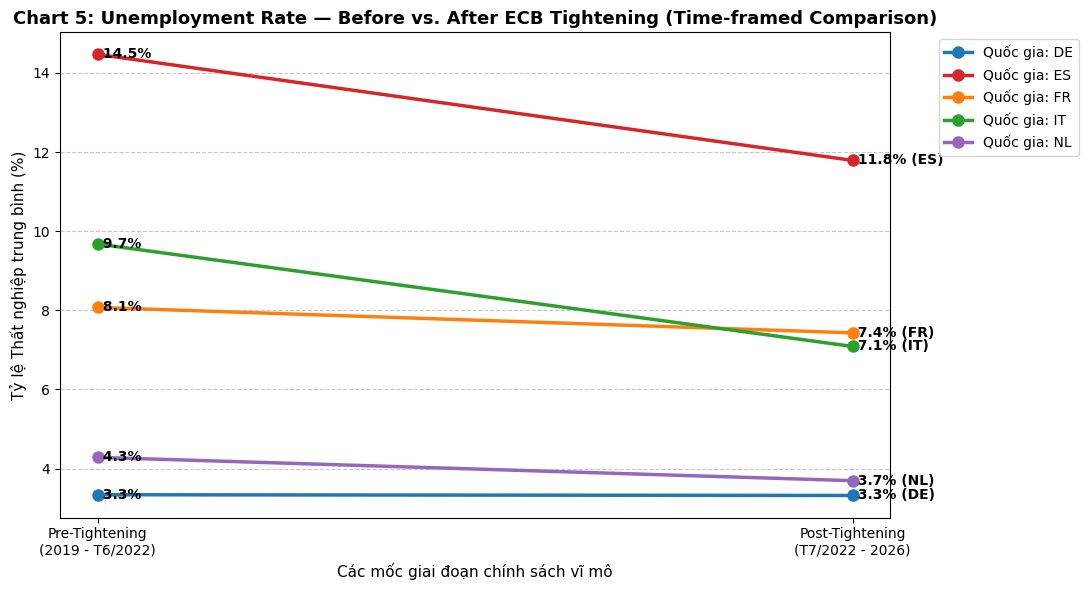

In [12]:
# ==========================================================
# CHART 4: Real GDP Growth (Small Multiples / Grouped Line)
# ==========================================================
plt.figure(figsize=(12, 6))
for country, grp in df.groupby("country"):
    plt.plot(grp["date"], grp["gdp_growth"], label=country, color=colors.get(country, "black"), linewidth=2)

plt.title("Chart 4: Real GDP Growth Trajectories across 5 Economies")
plt.ylabel("GDP Value / Growth")
plt.xlabel("Thời gian")
plt.axvline(pd.to_datetime("2022-07-01"), color="red", linestyle=":", label="Bắt đầu Tightening (2022)")
plt.legend(title="Quốc gia")
plt.show()


# ==========================================================
# CHART 5: Unemployment Rate Before vs. After Tightening (Có chú thích rõ mốc thời gian)
# ==========================================================
# Định nghĩa rõ ràng mốc thời gian để đưa vào biểu đồ và chú thích
# Pre-Tightening: Từ tháng 1/2019 đến hết tháng 6/2022
# Post-Tightening: Từ tháng 7/2022 đến hết giai đoạn hiện tại (2026)

pre_unemp = df[df["date"] < "2022-07-01"].groupby("country")["unemployment_rate"].mean()
post_unemp = df[df["date"] >= "2022-07-01"].groupby("country")["unemployment_rate"].mean()

df_unemp_compare = pd.DataFrame({
    "Pre-Tightening (2019 - T6/2022)": pre_unemp, 
    "Post-Tightening (T7/2022 - 2026)": post_unemp
}).reset_index()

plt.figure(figsize=(11, 6))

for i, row in df_unemp_compare.iterrows():
    country_code = row["country"]
    y_pre = row["Pre-Tightening (2019 - T6/2022)"]
    y_post = row["Post-Tightening (T7/2022 - 2026)"]
    
    # Vẽ đường nối độ dốc
    plt.plot(["Pre-Tightening\n(2019 - T6/2022)", "Post-Tightening\n(T7/2022 - 2026)"], 
             [y_pre, y_post], 
             marker="o", linewidth=2.5, markersize=8, 
             color=colors.get(country_code, "black"), label=f"Quốc gia: {country_code}")
    
    # Gắn nhãn số liệu trực tiếp bên cạnh các điểm dữ liệu
    plt.text("Pre-Tightening\n(2019 - T6/2022)", y_pre, f" {y_pre:.1f}%", verticalalignment='center', fontweight='bold')
    plt.text("Post-Tightening\n(T7/2022 - 2026)", y_post, f" {y_post:.1f}% ({country_code})", verticalalignment='center', fontweight='bold')

plt.title("Chart 5: Unemployment Rate — Before vs. After ECB Tightening (Time-framed Comparison)", fontsize=13, fontweight='bold')
plt.ylabel("Tỷ lệ Thất nghiệp trung bình (%)", fontsize=11)
plt.xlabel("Các mốc giai đoạn chính sách vĩ mô", fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()